## Data Science Intern Assignment: Data Science Task


The following is the solution for implementing machine learning for textual data to distinguish between comments that can be considered as cyberbullying or non-cyberbullying.

In [179]:
print("Let's begin! 🥳")

Let's begin! 🥳


### Exploratory Data Analysis (EDA)

#### Load data

Python package *pandas* is used to load the data. I will first begin with EDA. Here I will first check if there are any missing values or duplicates, and then finding statistics on the text length of the comments.

In [180]:
import pandas as pd

# Load the dataset
fpath = "CyberBullying Comments Dataset.csv" 
data_df = pd.read_csv(fpath)

missing_values = data_df.isnull().sum()  # Check for missing values and duplicates
duplicates = data_df.duplicated().sum()


# Analyze comment length distribution
data_df["Text_Length"] = data_df["Text"].apply(lambda x: len(str(x).split()))
text_length_stats = data_df["Text_Length"].describe()

print("Missing Values:\n", missing_values)
print("\nDuplicate Entries:", duplicates)
print("\nText Length Stats:\n", text_length_stats)
print(data_df["CB_Label"].value_counts())


Missing Values:
 Text        0
CB_Label    0
dtype: int64

Duplicate Entries: 0

Text Length Stats:
 count    11100.000000
mean        16.532613
std         17.287443
min          1.000000
25%          7.000000
50%         14.000000
75%         21.000000
max        703.000000
Name: Text_Length, dtype: float64
CB_Label
0    5550
1    5550
Name: count, dtype: int64


Here we see that the text count is at 11100 (count), where 5550 of the texts are assigned as cyberbullying (1), and the other 5550 assigned as non-cyberbullying (0).

#### Wordcloud
As this is a textual dataset, applying wordcloud will be beneficial to map the most frequent words when analyzing cyberbullying and non-cyberbullying comments seperately. 

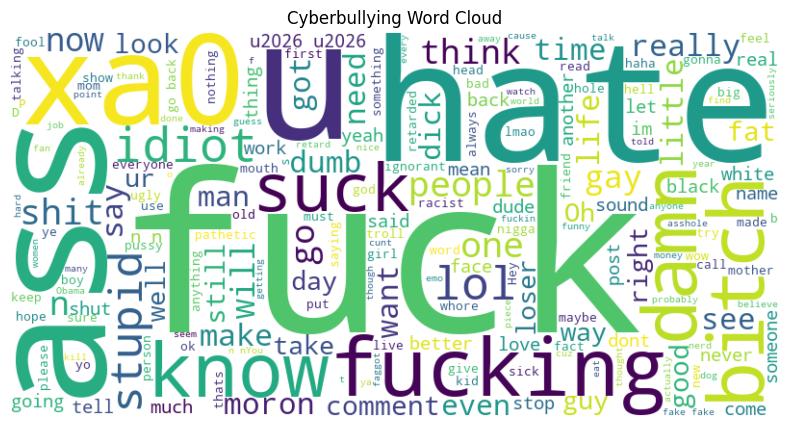

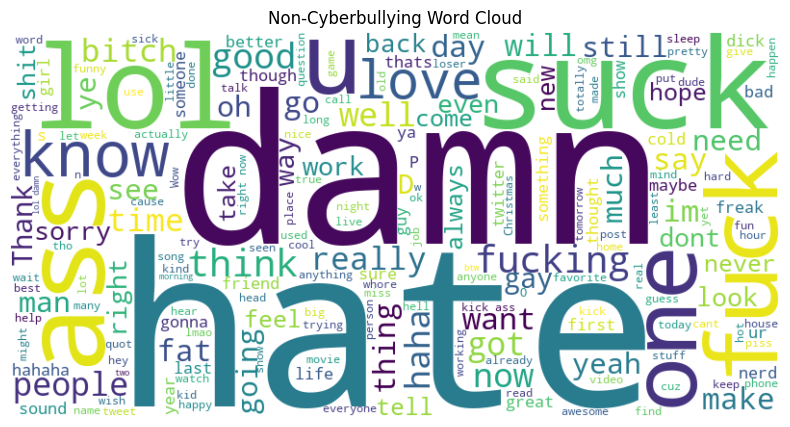

In [181]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Word cloud for cyberbullying comments
cyberbullying_text = " ".join(data_df[data_df["CB_Label"] == 1]["Text"])
wordcloud1 = WordCloud(width=800, height=400, background_color="white").generate(cyberbullying_text)

# Word cloud for non-cyberbullying comments
noncyberbullying_text = " ".join(data_df[data_df["CB_Label"] == 0]["Text"])
wordcloud0 = WordCloud(width=800, height=400, background_color="white").generate(noncyberbullying_text)

# Display word clouds
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud1, interpolation="bilinear")
plt.axis("off")
plt.title("Cyberbullying Word Cloud")
plt.show()

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud0, interpolation="bilinear")
plt.axis("off")
plt.title("Non-Cyberbullying Word Cloud")
plt.show()

As shown above, there are words that both categories share in terms of frequency (e.g. 'hate'). The most frequent words in the non-cyberbullying word cloud seem to have either neutral or negativ sentiment. It can be interpreted as many of the non-cyberbullying texts are either considered sarcasm, or simply friendly fire.

#### Sentiment analysis and plotting
Sentiment analysis will be appriopriate to understand how sentiment correlates to the cyberbullying label. Based on the word cloud shown earlier, I predict that the non-bullying category would lay not too far from neutral. Sentiment can also be used as a parameter for plotting a boxplot, providing visual representation of where the two categories lie. A histogram can show a visual representation of the text length of the comments, giving us insight of where the two categories lie in terms of text length.

CB_Label
0    0.022962
1   -0.113422
Name: Sentiment, dtype: float64


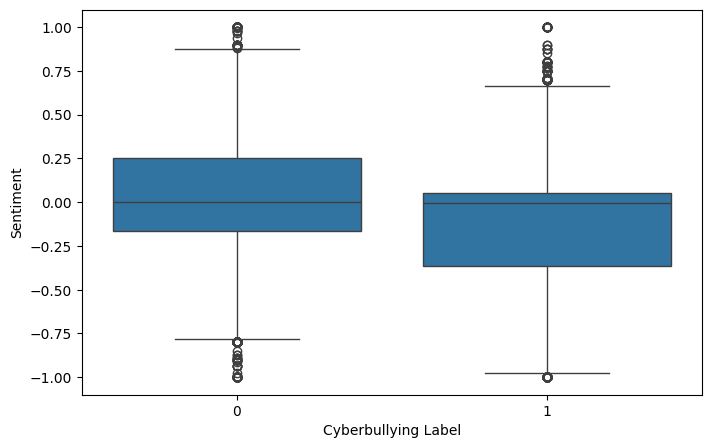

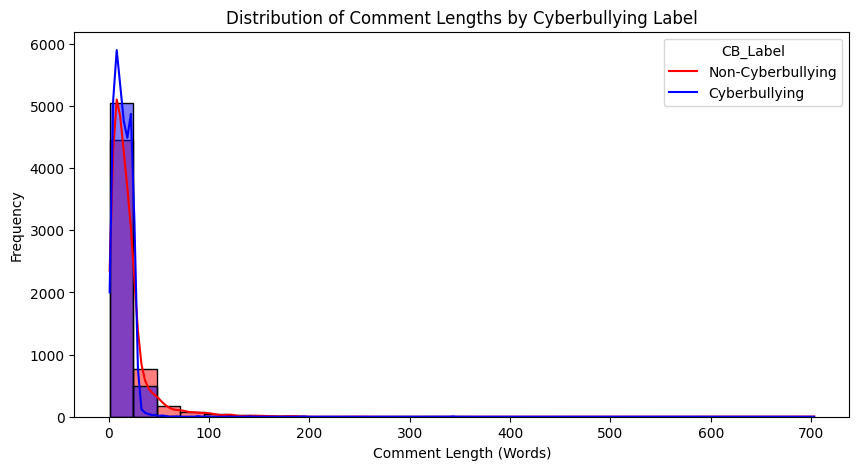

In [182]:
import seaborn as sns
from textblob import TextBlob

# Sentiment analysis
data_df["Sentiment"] = data_df["Text"].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
print(data_df.groupby("CB_Label")["Sentiment"].mean())

plt.figure(figsize=(8, 5))      #Boxplot
sns.boxplot(x="CB_Label", y="Sentiment", data=data_df)
plt.xlabel("Cyberbullying Label")
plt.ylabel("Sentiment")
plt.show()

# Histogram for comment length by label
plt.figure(figsize=(10, 5))
sns.histplot(data_df, x="Text_Length", hue="CB_Label", bins=30, kde=True, palette=["blue", "red"])
plt.xlabel("Comment Length (Words)")
plt.ylabel("Frequency")
plt.title("Distribution of Comment Lengths by Cyberbullying Label")
plt.legend(title="CB_Label", labels=["Non-Cyberbullying", "Cyberbullying"])
plt.show()

As shown above, the sentiment for non-cyberbullying is right at 0.022962, indicating the non-cyberbullying texts have neutral to slightly positive sentiment as average. Whereas the sentiment for cyberbullying is -0.113422, which is comparably farther from 0.0. This might indicate that the average texts tend to be negative. Since there is overlap between the two categories, the correlation between sentiment and cyberbullying indicates sentiment alone might not be sufficient for classification.

Looking at the histogram, there is a significant overlap between the two categories by the two lowest distributions, followed by the rest of the non-cyberbullying comments distributed further. We can further analyse this by calculating the mean and median of the comment lengths for each category to quantify the differences:




In [183]:
from scipy.stats import ttest_ind

print(f"mean text length: {data_df.groupby("CB_Label")["Text_Length"].mean()}")
print(f"median text length: {data_df.groupby("CB_Label")["Text_Length"].median()}")

# Split comment lengths by category
length_0 = data_df[data_df["CB_Label"] == 0]["Text_Length"]
length_1 = data_df[data_df["CB_Label"] == 1]["Text_Length"]

# Perform t-test
t_stat, p_value = ttest_ind(length_0, length_1)
print(f"T-statistic: {t_stat}, P-value: {p_value}")

mean text length: CB_Label
0    14.133333
1    18.931892
Name: Text_Length, dtype: float64
median text length: CB_Label
0    13.0
1    14.0
Name: Text_Length, dtype: float64
T-statistic: -14.764401273465833, P-value: 7.218680211117901e-49


The mean comment length for cyberbullying comments is significantly higher than non-cyberbullying comments, whilst the median comment length is slightly higher. This is counterintuitive based on the distribution illustraded on the histogram, which can be due to the mean being sensitive to outliers. The median values (14.0 words(1), 13 words(0)) indicate that there are a few cyberbullying texts that could be pulling the mean upwards.

The negative t-test indicate that the mean comment length for cyberbullying comments is significantly higher than for non-cyberbullying comments. The p-test indicate that the difference in comment lengths between the two categories is statistically significant.

For the feature selection, "Text", "Text_Length" & "Sentiment" will be used to train the model, since the two features can be considered significant when distinguishing between cyberbullying and non-cyberbullying texts.

### Preprocessing

The preprocessing steps prepare the data for later modeling with cleaner data as a result. NLP handles processing of textual data, which includes lowercasing, removing special characters, lemmatizing and the removal of stopwords:  

In [184]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from sklearn.model_selection import train_test_split


# Preprocessing
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r"[^a-zA-Z\s]", "", text)  # Remove special characters
    text = " ".join([lemmatizer.lemmatize(word) for word in text.split() if word not in stop_words])    #lemmatize
    return text

# Apply cleaning to the "Text" column
data_df["Cleaned_Text"] = data_df["Text"].apply(clean_text)

# Vectorization
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), binary=True)
X_text = vectorizer.fit_transform(data_df["Cleaned_Text"])
X_numeric = data_df[ ["Text_Length", "Sentiment"]].values
X_combined = hstack((X_text, X_numeric))

y = data_df["CB_Label"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42)

### Modeling

Now that the model is preprocessed, I can start with modeling. Since the dataset consists of two categories, using a model such as logistic regression would be suitable since it does not require a lot of computational source. It would also be beneficial to use a simple model for the sake of interpretability.

In [185]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_numeric_scaled = scaler.fit_transform(data_df[["Text_Length", "Sentiment"]].values)  # Scale numerical features

X_combined = hstack((X_text, X_numeric_scaled))

X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42)



# Logistic Regression
print("Logistic Regression:")
model_lr = LogisticRegression(max_iter=5000)
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

lr_report = classification_report(y_test, y_pred_lr, output_dict=False)
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_confmatrix = confusion_matrix(y_test, y_pred_lr)

print(f"Accuracy score: {round(lr_accuracy*100,2)}%")
print(f"Classification Report:\n {lr_report}")
print(f"Confusion Matrix:\n {lr_confmatrix}")


Logistic Regression:
Accuracy score: 72.16%
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.77      0.74      1128
           1       0.74      0.67      0.70      1092

    accuracy                           0.72      2220
   macro avg       0.72      0.72      0.72      2220
weighted avg       0.72      0.72      0.72      2220

Confusion Matrix:
 [[874 254]
 [364 728]]


#### Logistic regression with hyperparametric tuning 
Hyperparametric tuning can be used to identify and select optimal hyperparameters for training the model. It goes through several iterations where it tests different hyperparameter values until the best ones are identified. 

In [186]:
from sklearn.model_selection import GridSearchCV
import numpy as np

grid_values = {
    'C': [0.01,0.1,1,10],
    'penalty': ['l2'],
    'solver':["saga","lbfgs"],
}

grid_search_lr = LogisticRegression(random_state=42, max_iter=5000)

grid_search = GridSearchCV(estimator= grid_search_lr, param_grid=grid_values, cv=5, verbose=0, n_jobs=-1)
grid_search.fit(X_train, np.ravel(y_train, order="C"))

print(f"Best Hyperparameters after tuning: {grid_search.best_params_}")

best_model = grid_search.best_estimator_
gs_y_pred = best_model.predict(X_test)

hyperparameter_lr_accuracy = accuracy_score(y_test, gs_y_pred)
lrt_report = classification_report(y_test, y_pred_lr, output_dict=False)
lrt_confmatrix = confusion_matrix(y_test, y_pred_lr)

print(f"Accuracy score after tuning with hyperparameters: {round(hyperparameter_lr_accuracy*100,2)}%")
print(f"Classification Report after tuning:\n {lrt_report}")
print(f"Confusion Matrix after tuning:\n {lr_confmatrix}")


Best Hyperparameters after tuning: {'C': 1, 'penalty': 'l2', 'solver': 'saga'}
Accuracy score after tuning with hyperparameters: 72.39%
Classification Report after tuning:
               precision    recall  f1-score   support

           0       0.71      0.77      0.74      1128
           1       0.74      0.67      0.70      1092

    accuracy                           0.72      2220
   macro avg       0.72      0.72      0.72      2220
weighted avg       0.72      0.72      0.72      2220

Confusion Matrix after tuning:
 [[874 254]
 [364 728]]


#### Random Forest
Random Forest is another model, where it's key strength is it's control over overfitting. It also adaptive to capture complex, non-linear relationships between features, and it is also well equipped for binary classification tasks, ensuring both accuracy and reliability.

In [187]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

rf_report = classification_report(y_test, y_pred_rf, output_dict=False)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_confmatrix = confusion_matrix(y_test, y_pred_rf)

print(f"Accuracy score: {round(rf_accuracy*100,2)}%")
print(f"Classification Report:\n {rf_report}")
print(f"Confusion Matrix:\n {rf_confmatrix}")

Accuracy score: 72.03%
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.81      0.75      1128
           1       0.76      0.63      0.69      1092

    accuracy                           0.72      2220
   macro avg       0.73      0.72      0.72      2220
weighted avg       0.73      0.72      0.72      2220

Confusion Matrix:
 [[914 214]
 [407 685]]


### Evaluation

In [188]:

y_pred_best = best_model.predict(X_test)

best_accuracy = accuracy_score(y_test, y_pred_best)
best_report = classification_report(y_test, y_pred_best)
best_confmatrix = confusion_matrix(y_test, y_pred_best)

print(f"Best Model Accuracy: {round(best_accuracy*100,2)}%")
print(f"Best Model Classification Report:\n {best_report}")
print(f"Best Model Confusion Matrix:\n {best_confmatrix}")

Best Model Accuracy: 72.39%
Best Model Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.78      0.74      1128
           1       0.75      0.66      0.70      1092

    accuracy                           0.72      2220
   macro avg       0.73      0.72      0.72      2220
weighted avg       0.73      0.72      0.72      2220

Best Model Confusion Matrix:
 [[882 246]
 [367 725]]


In [ ]:
import joblib

# Save the best model
joblib.dump(best_model, "cyberbullying_classifier.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")

# Load the model and vectorizer
loaded_model = joblib.load("cyberbullying_classifier.pkl")
loaded_vectorizer = joblib.load("vectorizer.pkl")

# Sample prediction
sample_text = "I love pancakes"
cleaned_text = clean_text(sample_text)

vectorized_text = loaded_vectorizer.transform([cleaned_text])

# Add numerical features (Text_Length and Sentiment)
sample_text_length = len(sample_text.split())  
sample_sentiment = TextBlob(sample_text).sentiment.polarity  


sample_features = hstack((vectorized_text, np.array([[sample_text_length, sample_sentiment]])))

# Make prediction
prediction = loaded_model.predict(sample_features)
print("Sample Text Prediction:", "Cyberbullying" if prediction[0] == 1 else "Non-Cyberbullying")

Sample Text Prediction: Non-Cyberbullying
